# Blazed grating diffraction efficiency

Calculation of the diffraction efficiency for a blazed grating, as a function of photon energy, using `Blazr.m`'s VLS trajectory and blazed-grating efficiency solvers.

This uses the [`xreticolo`](https://pypi.org/project/xreticolo/) package, which wraps `Blazr.m` and shells out to `octave-cli` under the hood (no MATLAB license required).

awojdyla@lbl.gov -- October 2021 (ported to Python August 2026)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import xreticolo as xr

## Grating and beamline parameters

In [2]:
# grating parameters
g_lpm = 287.44e3
cff = 1.577
blazed_angle_deg = 0.40
material = "Au"

# VLS parameters
E_opt_eV = 806
pv_m = 24.301
qv_m = 7.573

# diffraction order
order = 1

## Energy sweep

For each photon energy: get the incidence angle from the VLS trajectory, then compute the +1 order diffraction efficiency of the blazed grating at that angle.

Each `vls_trajectory`/`efficiency_blazedx` call launches a short-lived Octave process, so this cell takes roughly a second per energy point.

In [3]:
Es_eV = np.linspace(250, 2500, 21)
eta1s = np.zeros_like(Es_eV)

for i, E_eV in enumerate(Es_eV):
    alpha_rad, beta_rad, theta_rad = xr.vls_trajectory(E_eV, E_opt_eV, g_lpm, pv_m, qv_m, cff)
    eta1s[i] = xr.efficiency_blazedx(
        g_lpm, blazed_angle_deg, E_eV, np.pi / 2 - alpha_rad, material, order
    )

eta1s

array([0.18765406, 0.25997706, 0.31778907, 0.35332256, 0.37856341,
       0.39176707, 0.39987207, 0.40248199, 0.40126448, 0.3914122 ,
       0.3784506 , 0.36306357, 0.34924252, 0.33240324, 0.31347114,
       0.29556951, 0.27776913, 0.25128497, 0.12957313, 0.1165537 ,
       0.12480155])

## Plot

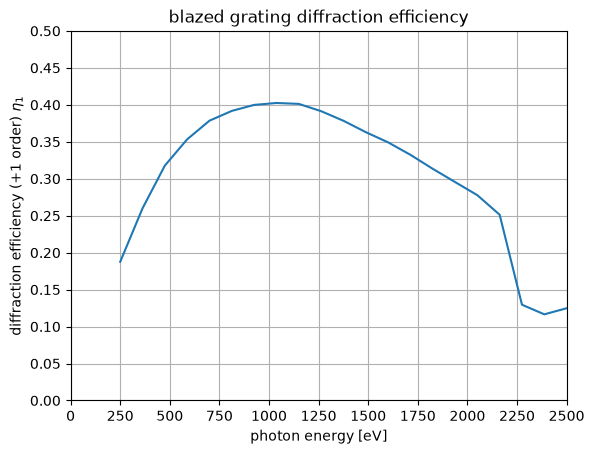

In [4]:
fig, ax = plt.subplots()
ax.plot(Es_eV, eta1s)
ax.set_title("blazed grating diffraction efficiency")
ax.set_xlabel("photon energy [eV]")
ax.set_ylabel(r"diffraction efficiency (+1 order) $\eta_1$")

ax.set_xlim(250, 2500)
ax.set_xticks(np.arange(0, 2501, 250))

ax.set_ylim(0, 0.5)
ax.set_yticks(np.arange(0, 0.51, 0.05))
ax.grid(True)

plt.show()